In [13]:
import sys
sys.path.append("../../src")

In [14]:
import numpy as np
from scipy.integrate import solve_ivp
from gaussian_systems.initial_state import generate_initial_mean_covariance as generate_inits
from gaussian_systems.systems import heisenberg_eom
from gaussian_systems.metrics import compute_logarithmic_negativity
from gaussian_systems.conventions import extract_mean_covariance

In [15]:
n = 2
nbars = np.array([0.0,0.0])
operation_tuple = (["1s",(0.5,0),1],["1s",(0.5,np.pi),2])

x0 = generate_inits(n=n,nbars=nbars,operation_tuple=operation_tuple)

In [16]:
frequency_tuple = (0.0,0.0)
decay_array = [("a",1,1),("a",2,1)]
dxdt = heisenberg_eom(n = n, frequency_tuple = frequency_tuple, decay_array = decay_array)

In [19]:
t_span = (0,40)
t_eval = np.linspace(t_span[0],t_span[1],150)
a_tol, r_tol = 1e-9, 1e-7
method = "Radau"
mysols = solve_ivp(fun=dxdt,y0=x0,t_span=t_span,t_eval=t_eval,method=method,a_tol=a_tol,r_tol=r_tol)

In [21]:
ts = mysols.t

In [35]:
ent = [compute_logarithmic_negativity(extract_mean_covariance(yt)[1]) for yt in mysols.y.T]

In [36]:
import matplotlib.pyplot as plt

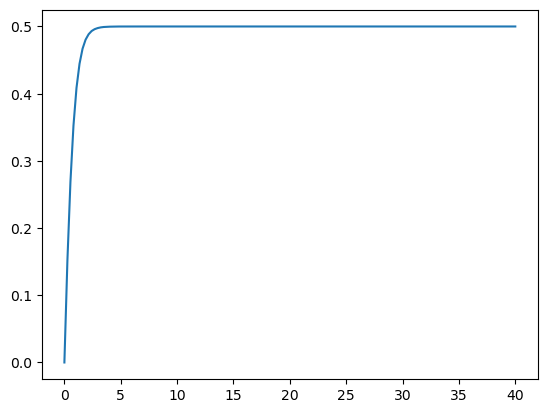

In [37]:
plt.plot(ts, ent)